# RenalScan — 04: Quantitative Kidney Stone Dimension Measurement

This notebook implements and evaluates the quantitative physical measurement module:
1. **Full Pipeline Integration**: Combines YOLOv8 Detection, Classical CV Segmentation, and Geometric Contour Measurement.
2. **Dimension Extractions**: Calculates Major Axis ($px$), Minor Axis ($px$), Mask Area ($px^2$), Equivalent Diameter ($px$), and Aspect Ratio.
3. **Literature-Based Approx. mm Conversion**: Converts pixel dimensions using a literature-based baseline constant ($0.70\text{ mm/px}$, derived from typical $360\text{ mm}$ abdominal CT FOV / $512\text{ px}$ matrix).
4. **Clinical Size Banding**: Classifies stones into urological treatment bands ($<4\text{mm}$, $4-6\text{mm}$, $6-10\text{mm}$, $>10\text{mm}$).
5. **Non-Clinical Disclaimer**: All mm-based measurements are explicitly tagged as **estimated, non-clinical** metrics and must not be used for diagnostic decisions.
6. **Visual Axis Overlay Plots**: Renders Major Axis (cyan line) and Minor Axis (yellow line) vectors overlaid on CT scans.

In [1]:
import os
import sys
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.detection.predict import StoneDetector
from src.segmentation.segment import StoneSegmenter
from src.measurement.measure import StoneMeasurer, ASSUMED_MM_PER_PIXEL, NON_CLINICAL_DISCLAIMER

MODELS_DIR = PROJECT_ROOT / "models"
TEST_IMG_DIR = PROJECT_ROOT / "data" / "test" / "images"

detector = StoneDetector(model_path=MODELS_DIR / "detection_best.pt")
segmenter = StoneSegmenter(padding_pct=0.10)
measurer = StoneMeasurer(mm_per_pixel=ASSUMED_MM_PER_PIXEL)

print(f"Initialized StoneMeasurer (Assumed mm/px factor = {ASSUMED_MM_PER_PIXEL})")
print(f"Disclaimer: {NON_CLINICAL_DISCLAIMER}")

Loaded StoneDetector weights from: C:\Users\akhil\Desktop\Renal Scan\models\detection_best.pt
Initialized StoneMeasurer (Assumed mm/px factor = 0.7)
Disclaimer: Estimated, non-clinical value (assumed 0.70 mm/px). Not for diagnostic or surgical decisions.


In [2]:
# Select 10 test CT images for dimension measurement evaluation
test_image_paths = sorted(list(TEST_IMG_DIR.glob("*.jpg")))[:10]
print(f"Selected {len(test_image_paths)} test CT scans for quantitative dimension measurement.")

Selected 10 test CT scans for quantitative dimension measurement.


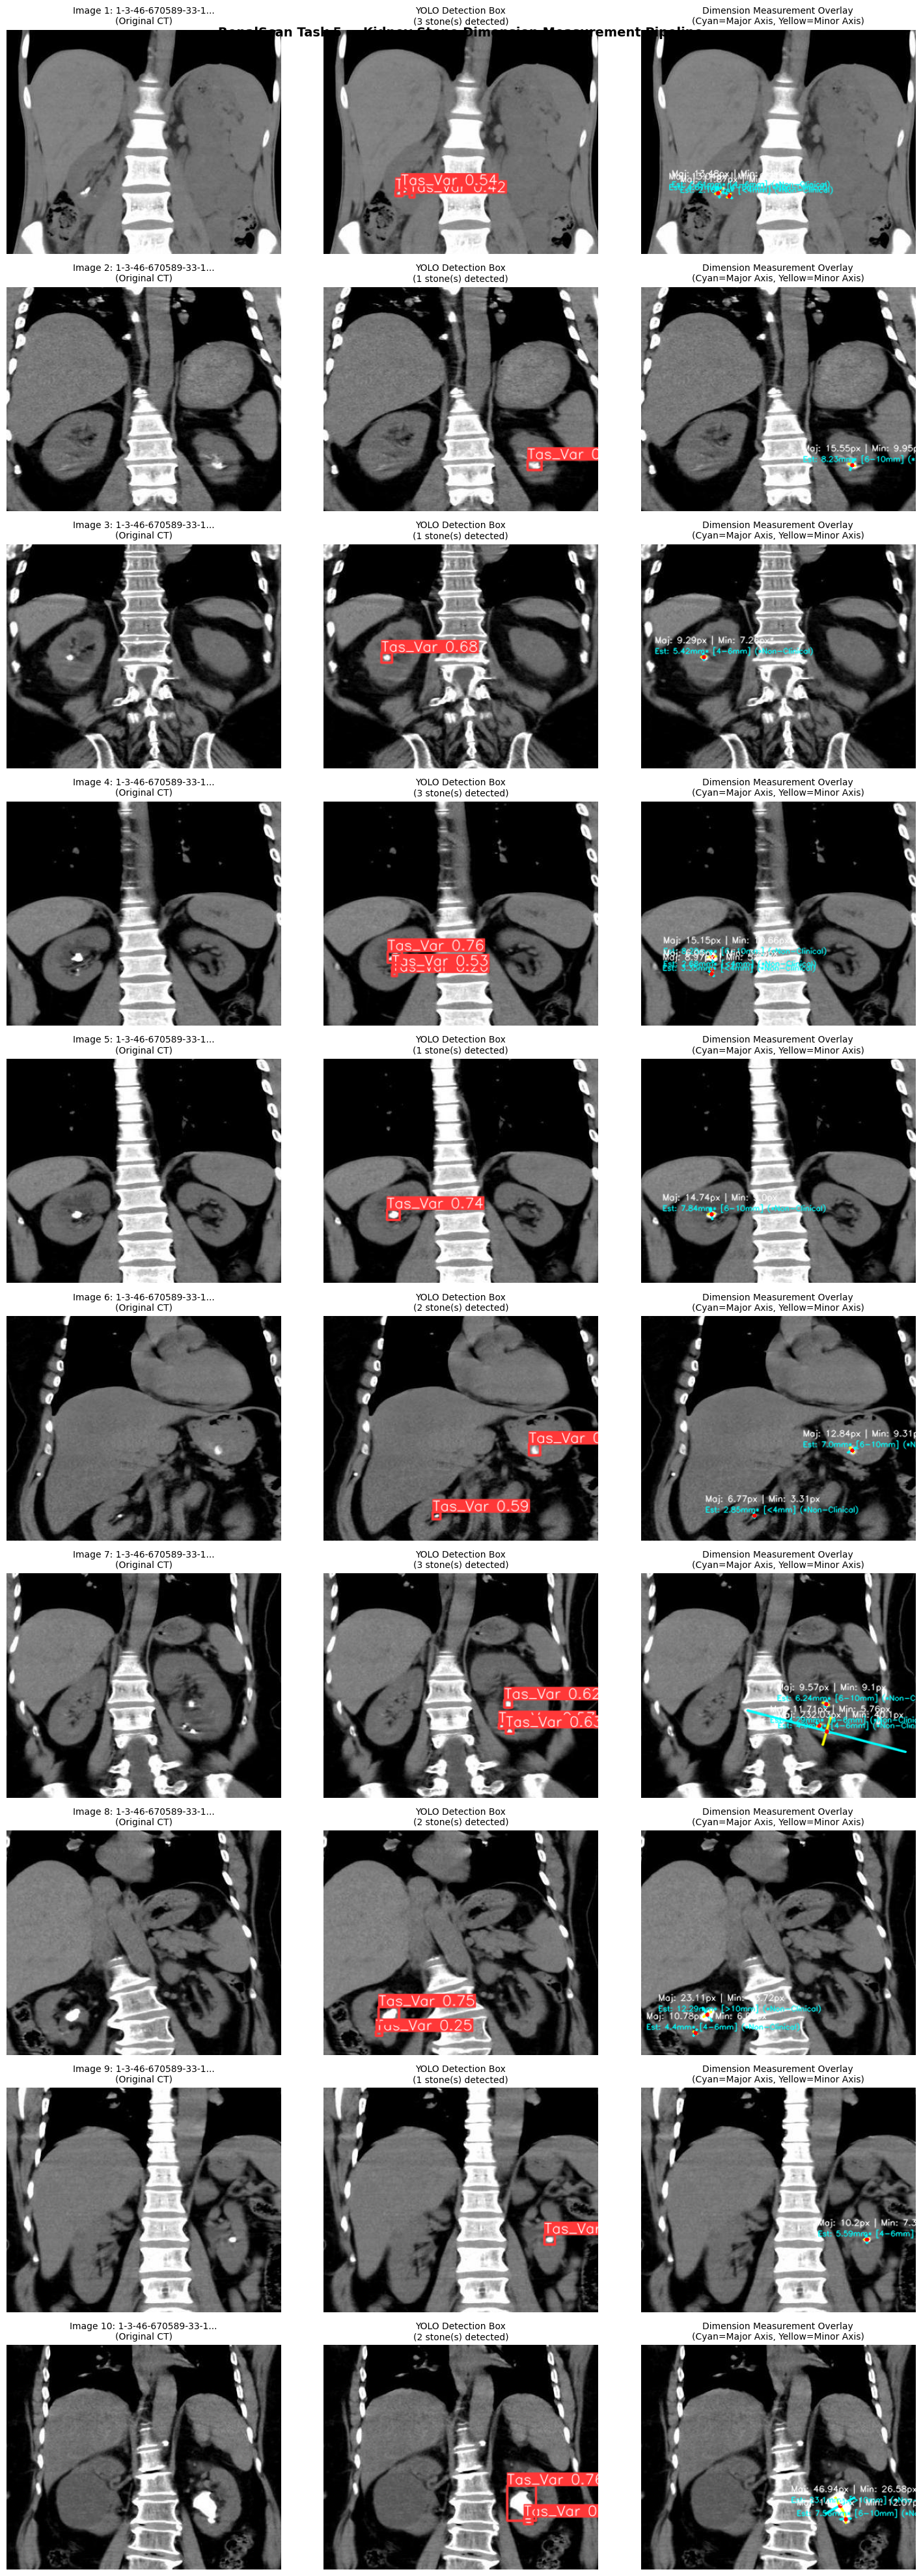

Saved measurement visualization plot to: C:\Users\akhil\Desktop\Renal Scan\notebooks\measurement_sample_overlays.png


In [3]:
# Run Detection -> Segmentation -> Measurement Pipeline & generate visual axis plots
measurement_records = []
fig, axes = plt.subplots(len(test_image_paths), 3, figsize=(15, 4 * len(test_image_paths)))

for i, img_path in enumerate(test_image_paths):
    bgr_img = cv2.imread(str(img_path))
    rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    
    # 1. Detection
    annotated_bgr, detections = detector.predict(rgb_img, conf_thresh=0.25)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    
    # 2. Segmentation
    seg_results = segmenter.segment_image_detections(rgb_img, detections)
    
    # 3. Measurement
    measured_results = measurer.measure_segmentation_results(seg_results)
    
    # Render Measurement Axis Overlay Plot
    axis_overlay = rgb_img.copy()
    
    for idx, m in enumerate(measured_results):
        if m.get('area_px', 0) > 0:
            axis_overlay = measurer.draw_measurement_overlay(axis_overlay, m, draw_text=True)
            
            measurement_records.append({
                'Sample #': i + 1,
                'Filename': img_path.name[:22] + "...",
                'Stone #': idx + 1,
                'Major Axis (px)': m['major_axis_px'],
                'Minor Axis (px)': m['minor_axis_px'],
                'Mask Area (px²)': m['area_px'],
                'Equiv Diam (px)': m['equiv_diameter_px'],
                'Est Diam (mm)*': m['estimated_diameter_mm'],
                'Clinical Size Band': m['clinical_size_band']
            })
            
    # Plot Subplots
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"Image {i+1}: {img_path.name[:18]}...\n(Original CT)", fontsize=10)
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(annotated_rgb)
    axes[i, 1].set_title(f"YOLO Detection Box\n({len(detections)} stone(s) detected)", fontsize=10)
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(axis_overlay)
    axes[i, 2].set_title(f"Dimension Measurement Overlay\n(Cyan=Major Axis, Yellow=Minor Axis)", fontsize=10)
    axes[i, 2].axis("off")

plt.suptitle("RenalScan Task 5 — Kidney Stone Dimension Measurement Pipeline", fontsize=14, fontweight='bold')
plt.tight_layout()
meas_plot_path = PROJECT_ROOT / "notebooks" / "measurement_sample_overlays.png"
plt.savefig(meas_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved measurement visualization plot to: {meas_plot_path}")

In [4]:
# 4. Display Quantitative Measurement Summary Table
df_meas = pd.DataFrame(measurement_records)
print("===========================================================================================")
print("RENALSCAN TASK 5 — QUANTITATIVE KIDNEY STONE MEASUREMENT LOG (ESTIMATED NON-CLINICAL)")
print("===========================================================================================")
print(f"*DISCLAIMER: {NON_CLINICAL_DISCLAIMER}")
print("-------------------------------------------------------------------------------------------")
if not df_meas.empty:
    print(df_meas.to_string(index=False))
else:
    print("No stone contours measured in selected samples.")

RENALSCAN TASK 5 — QUANTITATIVE KIDNEY STONE MEASUREMENT LOG (ESTIMATED NON-CLINICAL)
*DISCLAIMER: Estimated, non-clinical value (assumed 0.70 mm/px). Not for diagnostic or surgical decisions.
-------------------------------------------------------------------------------------------
 Sample #                  Filename  Stone #  Major Axis (px)  Minor Axis (px)  Mask Area (px²)  Equiv Diam (px)  Est Diam (mm)*                                   Clinical Size Band
        1 1-3-46-670589-33-1-637...        1            13.48             5.94             50.5             8.02            5.61         4-6mm (Medium - Moderate passage likelihood)
        1 1-3-46-670589-33-1-637...        2            11.87             6.73              7.5             3.09            2.16               <4mm (Small - High passage likelihood)
        1 1-3-46-670589-33-1-637...        3            13.04             6.71             35.0             6.68            4.67         4-6mm (Medium - Moderate passage